# Import packages

In [2]:
# My own utility functions
from utils import perform_mutation, pack, relax_structure, visualize, run_analysis

In [3]:
# Python
from pyrosetta import *
from pyrosetta.rosetta import *
from pyrosetta.teaching import *
from pyrosetta.toolbox import *

# Core Includes
# from rosetta.core.kinematics import MoveMap
from pyrosetta.rosetta.core.kinematics import FoldTree
from rosetta.core.pack.task import TaskFactory
from rosetta.core.pack.task import operation
from rosetta.core.simple_metrics import metrics
from rosetta.core.select import residue_selector as selections
from rosetta.core import select
from rosetta.core.select.movemap import *

# Protocol Includes
from rosetta.protocols import minimization_packing as pack_min
from rosetta.protocols import relax as rel
from rosetta.protocols.antibody.residue_selector import CDRResidueSelector
from rosetta.protocols.antibody import *
from rosetta.protocols.loops import *
from rosetta.protocols.relax import FastRelax

# Initial Set up

In [4]:
# Intialize pyrosetta 
init(options=[
    '-use_input_sc',
    '-input_ab_scheme', 'AHo_Scheme',
    '-ignore_unrecognized_res',
    '-ignore_zero_occupancy', 'false',
    '-load_PDB_components', 'false',
    '-relax:default_repeats', '2',
    '-no_fconfig',
    '-mute', 'all'  
])

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.conda.ubuntu.cxx11thread.serialization.Ubuntu.python313.Release 2026.26+release.f8a8eab4344af49c25e1e5db84ce25fec05eea27 2026-06-25T18:00:21] retrieved from: http://www.pyrosetta.org


In [5]:
# Load pdb file
pose = pose_from_pdb('pdb_files/7K18.pdb')

# Ensure pdb file is correct
print(pose.sequence())
print(pose.residue(958).name())
print(len(pose.sequence()))

VRRAAVKILVHSLFSMLIMCTILTNCVFMAQHDPPPWTKYVEYTFTAIYTFESLVKILARGFCLHAFTFLRDPWNWLDFSVIVMAYTTEFVDGNVSALRTFRVLRALKTISVISGLKTIVGALIQSVKKLADVMVLTVFCLSVFALIGLQLFMGNLRHKCVRNFTELNGTNGSVEASLDVYLNDPANYLLKNGTTDVLLCGNSSDAGTCPEGYRCLKAGENPDHGYTSFDSFAWAFLALFRLMTQDCWERLYQQTLRSAGKIYMIFFMLVIFLGSFYLVNLILAVVAMAYEEQNQATECCPLWMSIKQKVKFVVMDPFADLTITMCIVLNTLFMALEHYNMTAEFEEMLQVGNLVFTGIFTAEMTFKIIALDPYYYFQQGWNIFDSIIVILSLMELGSVLRSFRLLRVFKLAKSWPTLNTLIKIIGNSVGALGNLTLVLAIIVFIFAVVGMQLFGKNYSELRHRISDSGLLPRWHMMDFFHAFLIIFRILCGEWIETMWDCMEVSGQSLCLLVFLLVMVIGNLVVLNLFLALLLSSFGKVWWRLRKTCYRIVEHSWFETFIIFMILLSSGALAFEDIYLEERKTIKVLLEYADKMFTYVFVLEMLLKWVAYGFKKYFTNAWCWLDFLIVDVSLVSLVANTLGFAEMGPIKSLRTLRALRPLRALSRFEGMRVVVNALVGAIPSIMNVLLVCLIFWLIFSIMGVNLFAGKFGRCINQTEGDLPLNYTIVNNKSECESFNVTGELYWTKVKVNFDNVGAGYLALLQVATFKGWMDIMYAAVDSRGYEEQPQWEDNLYMYIYFVVFIIFGSFFTLNLFIGVIIDNFNQQKKKLGGQDIFMTEEQKKYYNAMKKLGSKKPQKPIPRPLNKYQGFIFDIVTKQAFDVTIMFLICLNMVTMMVETDDQSPEKVNILAKINLLFVAIFTGECIVKMAALRHYYFTNSWNIFDFVVVILSIVGTVLSDIIQKYFFSPTLFRVIRLARIGRILRLIRGAKGIRTLLFAL

In [6]:
# truncate pose to only include residues of interest
# This includes the 67 AA in the toxin
# And 100 AA on NaV1.5 around LSDLIQ (where toxin interacts with NaV1.5)
trunc_pose = Pose()
trunc_pose.assign(pose)
pyrosetta.rosetta.protocols.grafting.delete_region(trunc_pose,1,899)
pyrosetta.rosetta.protocols.grafting.delete_region(trunc_pose,101,229)
print(trunc_pose.sequence())

DDQSPEKVNILAKINLLFVAIFTGECIVKMAALRHYYFTNSWNIFDFVVVILSIVGTVLSDIIQKYFFSPTLFRVIRLARIGRILRLIRGAKGIRTLLFAVRDGYIAQPENCVYHCFPGSSGCDTLCKEKGGTSGHCGFKVGHGLACWCNALPDNVGIIVEGEKCHS


In [7]:
# relax the structure (view utils.py to see how this works)
relax_structure(trunc_pose, 'pdb_files/7K18_relax.pdb')

PDB file name: pdb_files/7K18.pdb
Total residues: 167
Sequence: DDQSPEKVNILAKINLLFVAIFTGECIVKMAALRHYYFTNSWNIFDFVVVILSIVGTVLSDIIQKYFFSPTLFRVIRLARIGRILRLIRGAKGIRTLLFAVRDGYIAQPENCVYHCFPGSSGCDTLCKEKGGTSGHCGFKVGHGLACWCNALPDNVGIIVEGEKCHS
Fold tree:
FOLD_TREE  EDGE 1 100 -1  EDGE 1 101 1  EDGE 101 167 -1 


# Analysis

## Notes 

### Color Key
- **Cyan** – NaV1.5 protein
- **Purple** – LqhIII scorpion toxin
- **Yellow** – Histidine residues that bind to NaV1.5
- **Green** – **LSDLIQ** motif, a region important for toxin binding
  - The **aspartate (D)** residue is particularly important, as it serves as an anchor point for the histidine residues.

### Mutation
In the visualization below, the **LSDLIQ** motif has been mutated to **MSDLIQ** by replacing **Leucine (L)** with **Methionine (M)**

### PyMOL Sessions

PyMOL session files (`.pse`) are also generated in the `sessions/` directory if you would like to further explore or analyze the structures interactively.

#Packer_Task

Threads to request: ALL AVAILABLE

resid	pack?	design?	allowed_aas
1	FALSE	FALSE	
2	FALSE	FALSE	
3	FALSE	FALSE	
4	FALSE	FALSE	
5	FALSE	FALSE	
6	FALSE	FALSE	
7	FALSE	FALSE	
8	FALSE	FALSE	
9	FALSE	FALSE	
10	FALSE	FALSE	
11	FALSE	FALSE	
12	FALSE	FALSE	
13	FALSE	FALSE	
14	FALSE	FALSE	
15	FALSE	FALSE	
16	FALSE	FALSE	
17	FALSE	FALSE	
18	FALSE	FALSE	
19	FALSE	FALSE	
20	FALSE	FALSE	
21	FALSE	FALSE	
22	FALSE	FALSE	
23	FALSE	FALSE	
24	FALSE	FALSE	
25	FALSE	FALSE	
26	FALSE	FALSE	
27	FALSE	FALSE	
28	FALSE	FALSE	
29	FALSE	FALSE	
30	FALSE	FALSE	
31	FALSE	FALSE	
32	FALSE	FALSE	
33	FALSE	FALSE	
34	FALSE	FALSE	
35	FALSE	FALSE	
36	FALSE	FALSE	
37	FALSE	FALSE	
38	FALSE	FALSE	
39	FALSE	FALSE	
40	FALSE	FALSE	
41	FALSE	FALSE	
42	FALSE	FALSE	
43	FALSE	FALSE	
44	FALSE	FALSE	
45	FALSE	FALSE	
46	FALSE	FALSE	
47	FALSE	FALSE	
48	FALSE	FALSE	
49	FALSE	FALSE	
50	FALSE	FALSE	
51	FALSE	FALSE	
52	FALSE	FALSE	
53	FALSE	FALSE	
54	TRUE	FALSE	ILE
55	TRUE	FALSE	VAL
56	TRUE	FALSE	GLY
57	TRUE	FALSE	THR
58	TRUE	

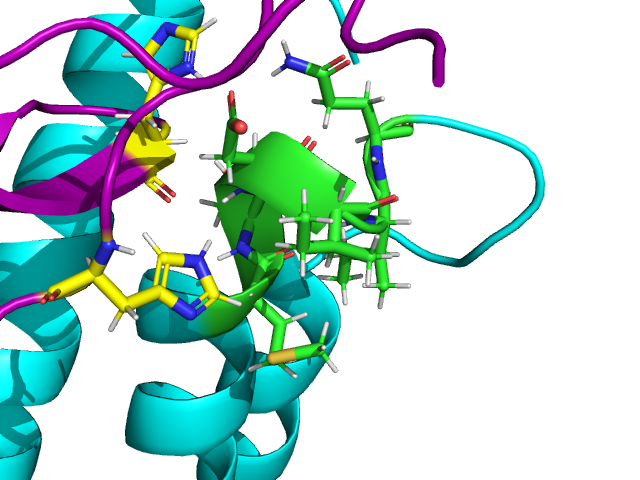

In [8]:
run_analysis('pdb_files/7K18_relax.pdb', 59, 'M')

#Packer_Task

Threads to request: ALL AVAILABLE

resid	pack?	design?	allowed_aas
1	FALSE	FALSE	
2	FALSE	FALSE	
3	FALSE	FALSE	
4	FALSE	FALSE	
5	FALSE	FALSE	
6	FALSE	FALSE	
7	FALSE	FALSE	
8	FALSE	FALSE	
9	FALSE	FALSE	
10	FALSE	FALSE	
11	FALSE	FALSE	
12	FALSE	FALSE	
13	FALSE	FALSE	
14	FALSE	FALSE	
15	FALSE	FALSE	
16	FALSE	FALSE	
17	FALSE	FALSE	
18	FALSE	FALSE	
19	FALSE	FALSE	
20	FALSE	FALSE	
21	FALSE	FALSE	
22	FALSE	FALSE	
23	FALSE	FALSE	
24	FALSE	FALSE	
25	FALSE	FALSE	
26	FALSE	FALSE	
27	FALSE	FALSE	
28	FALSE	FALSE	
29	FALSE	FALSE	
30	FALSE	FALSE	
31	FALSE	FALSE	
32	FALSE	FALSE	
33	FALSE	FALSE	
34	FALSE	FALSE	
35	FALSE	FALSE	
36	FALSE	FALSE	
37	FALSE	FALSE	
38	FALSE	FALSE	
39	FALSE	FALSE	
40	FALSE	FALSE	
41	FALSE	FALSE	
42	FALSE	FALSE	
43	FALSE	FALSE	
44	FALSE	FALSE	
45	FALSE	FALSE	
46	FALSE	FALSE	
47	FALSE	FALSE	
48	FALSE	FALSE	
49	FALSE	FALSE	
50	FALSE	FALSE	
51	FALSE	FALSE	
52	FALSE	FALSE	
53	FALSE	FALSE	
54	FALSE	FALSE	
55	FALSE	FALSE	
56	FALSE	FALSE	
57	TRUE	FALSE	THR
58	TRUE	FALSE	

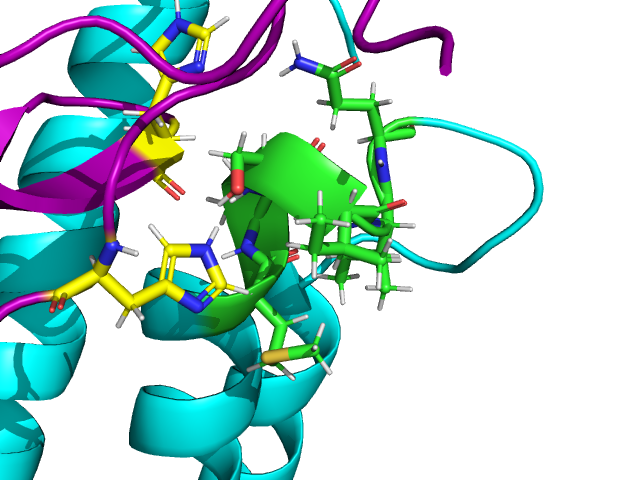

In [9]:
run_analysis('pdb_files/7K18_relax_59M.pdb', 61, 'S')